L’objectif de ce notebook est de construire un **dataset maître multimodal**.

Le projet travaille avec des paires images + rapport. Par conséquent, afin qu'une ligne soit exploitable elle doit contenir : 

- le chemin local d’une radiographie thoracique ;
- le rapport médical associé à cette même radiographie ;
- une clé commune permettant de vérifier que l’image et le rapport correspondent bien.

À la fin de ce notebook, on aura un fichier propre `matched_image_reports.csv`qui servira ensuite pour :

- EDA ;
- la création des paires cohérentes et incohérentes ;
- l’entraînement du modèle multimodal image + texte ;
- etc.


In [1]:
import pandas as pd
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
df_chex_small = pd.read_csv("../data/raw/chexpert_small/train.csv")
df_chex_small.shape

(223414, 19)

In [3]:
df_chex_small.head()

,Path,Sex,Age,Frontal/Lateral,AP/PA,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices
0,CheXpert-v1.0-small/train/patient00001/study1/...,Female,68,Frontal,AP,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,1.0
1,CheXpert-v1.0-small/train/patient00002/study2/...,Female,87,Frontal,AP,NaN,NaN,-1.0,1.0,NaN,-1.0,-1.0,NaN,-1.0,NaN,-1.0,NaN,1.0,NaN
2,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Frontal,AP,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
3,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Lateral,NaN,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
4,CheXpert-v1.0-small/train/patient00003/study1/...,Male,41,Frontal,AP,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN


In [4]:
df_reports = pd.read_csv("../data/raw/chexpert_plus/df_chexpert_plus_240401.csv")

df_reports.shape

(223462, 27)

In [5]:
df_reports.head()

,path_to_image,path_to_dcm,frontal_lateral,ap_pa,deid_patient_id,patient_report_date_order,report,section_narrative,section_clinical_history,section_history,...,section_accession_number,age,sex,race,ethnicity,interpreter_needed,insurance_type,recent_bmi,deceased,split
0,train/patient42142/study5/view1_frontal.jpg,train/patient42142/study5/view1_frontal.dcm,Frontal,AP,patient42142,5,"NARRATIVE:\nChest 1 View, 8-8-2005\n \nHISTORY...","\nChest 1 View, 8-8-2005\n \n",NaN,"61 years Female, ICU patient\n \n",...,\n 9959089\nThis report has been anonymized. A...,62.0,Female,White,Non-Hispanic/Non-Latino,No,Private Insurance,22.2,No,train
1,train/patient42142/study8/view1_frontal.jpg,train/patient42142/study8/view1_frontal.dcm,Frontal,AP,patient42142,8,"NARRATIVE:\nChest 1 View, 7-11-2000\n \nHISTOR...","\nChest 1 View, 7-11-2000\n \n",NaN,"61 years Female, tracheostomy.\n \n",...,\n64048857\nThis report has been anonymized. A...,62.0,Female,White,Non-Hispanic/Non-Latino,No,Private Insurance,22.2,No,train
2,train/patient42142/study2/view1_frontal.jpg,train/patient42142/study2/view1_frontal.dcm,Frontal,AP,patient42142,2,"NARRATIVE:\nChest 1 View, 11-17-2018\n \nHISTO...","\nChest 1 View, 11-17-2018\n \n",NaN,"61 years Female, critical care follow-up\n \n",...,\n#2452\nThis report has been anonymized. All ...,62.0,Female,White,Non-Hispanic/Non-Latino,No,Private Insurance,22.2,No,train
3,train/patient42142/study4/view1_frontal.jpg,train/patient42142/study4/view1_frontal.dcm,Frontal,AP,patient42142,4,NARRATIVE:\nAP PORTABLE UPRIGHT CHEST: May 01 ...,\nAP PORTABLE UPRIGHT CHEST: May 01 at 0518 ho...,ICU protocol. Follow up.\n \n,NaN,...,\n4164064\nThis report has been anonymized. Al...,62.0,Female,White,Non-Hispanic/Non-Latino,No,Private Insurance,22.2,No,train
4,train/patient42142/study3/view1_frontal.jpg,train/patient42142/study3/view1_frontal.dcm,Frontal,AP,patient42142,3,"NARRATIVE:\nEXAM: Chest 1 View, 10/4/2\n \nCLI...","\nEXAM: Chest 1 View, 10/4/2\n \n",61 years Female UPRIGHT PLEASE. ICU PROTOCOL ...,NaN,...,\n49286401\nThis report has been anonymized. A...,62.0,Female,White,Non-Hispanic/Non-Latino,No,Private Insurance,22.2,No,train


In [7]:
df_reports.columns

Index(['path_to_image', 'path_to_dcm', 'frontal_lateral', 'ap_pa',
       'deid_patient_id', 'patient_report_date_order', 'report',
       'section_narrative', 'section_clinical_history', 'section_history',
       'section_comparison', 'section_technique', 'section_procedure_comments',
       'section_findings', 'section_impression', 'section_end_of_impression',
       'section_summary', 'section_accession_number', 'age', 'sex', 'race',
       'ethnicity', 'interpreter_needed', 'insurance_type', 'recent_bmi',
       'deceased', 'split'],
      dtype='object')

In [5]:
# df_min = df_reports[['path_to_image','frontal_lateral','deid_patient_id','section_findings','section_impression','section_summary','report']]
# df_min.head(10)

In [7]:
df_reports["path_to_image"].head(10)

0    train/patient42142/study5/view1_frontal.jpg
1    train/patient42142/study8/view1_frontal.jpg
2    train/patient42142/study2/view1_frontal.jpg
3    train/patient42142/study4/view1_frontal.jpg
4    train/patient42142/study3/view1_frontal.jpg
5    train/patient42142/study7/view1_frontal.jpg
6    train/patient42142/study1/view1_frontal.jpg
7    train/patient42142/study6/view1_frontal.jpg
8    train/patient04528/study1/view2_lateral.jpg
9    train/patient04528/study1/view1_frontal.jpg
Name: path_to_image, dtype: object

In [13]:
df_reports["path_to_image"].tail(5)

223457    train/patient59696/study1/view1_frontal.jpg
223458    train/patient24732/study1/view1_frontal.jpg
223459    train/patient12591/study1/view1_frontal.jpg
223460    train/patient37553/study1/view1_frontal.jpg
223461    train/patient48017/study1/view1_frontal.jpg
Name: path_to_image, dtype: object

 On va maintenant lister les chemins locaux des images pour les comparer aux chemins qui figurent sur le fichier de Stanford chexpert_plus (df_reports["path_to_image"]). Ceci nous permettra de normaliser le chemin de référence dans les 
 datasets afin qu'on puisse faire ensuite une jointure en nous basant sur ce chemin de référence. Cette jointure c'est ce qui nous permettra d'obtenir un dataset avec à la fois le rapport et le chemin exact vers l'image qui y correspond

In [ ]:

#Créer un objet Path qui pointe vers le dossier qui contient les images
image_root = Path("../data/raw/chexpert_small")

#rglob (Recursive Glob) cherche récursivement, dans le dossier en question, tous les fichiers correspondant à
#  un motif (jpg pour les images dans notre cas)
#  on les stocke ensuite dans un objet List pouor pouvoir récupérer tous les résultats immédiatement
images = list(image_root.rglob("*.jpg"))

len(images)

223649

In [11]:
images[:10]

[WindowsPath('../data/raw/chexpert_small/valid/patient64740/study1/view1_frontal.jpg'),
 WindowsPath('../data/raw/chexpert_small/valid/patient64739/study1/view1_frontal.jpg'),
 WindowsPath('../data/raw/chexpert_small/valid/patient64738/study1/view1_frontal.jpg'),
 WindowsPath('../data/raw/chexpert_small/valid/patient64737/study1/view1_frontal.jpg'),
 WindowsPath('../data/raw/chexpert_small/valid/patient64736/study1/view1_frontal.jpg'),
 WindowsPath('../data/raw/chexpert_small/valid/patient64735/study1/view1_frontal.jpg'),
 WindowsPath('../data/raw/chexpert_small/valid/patient64734/study1/view1_frontal.jpg'),
 WindowsPath('../data/raw/chexpert_small/valid/patient64733/study1/view1_frontal.jpg'),
 WindowsPath('../data/raw/chexpert_small/valid/patient64732/study1/view1_frontal.jpg'),
 WindowsPath('../data/raw/chexpert_small/valid/patient64731/study1/view1_frontal.jpg')]

In [12]:
images[-5:]

[WindowsPath('../data/raw/chexpert_small/train/patient00002/study1/view1_frontal.jpg'),
 WindowsPath('../data/raw/chexpert_small/train/patient00002/study1/view2_lateral.jpg'),
 WindowsPath('../data/raw/chexpert_small/train/patient00002/study2/view1_frontal.jpg'),
 WindowsPath('../data/raw/chexpert_small/train/patient00001/study1/._view1_frontal.jpg'),
 WindowsPath('../data/raw/chexpert_small/train/patient00001/study1/view1_frontal.jpg')]

On peut constater l'existence de certains fichiers parasytes dans images qui commencent par ._view1_frontal.jpg. Il faut donc les supprimer 

In [31]:
images = [
    p for p in images
    if p.name.endswith(".jpg") and not p.name.startswith("._")
]

In [32]:
images[-5:]

[WindowsPath('../data/raw/chexpert_small/train/patient00003/study1/view1_frontal.jpg'),
 WindowsPath('../data/raw/chexpert_small/train/patient00002/study1/view1_frontal.jpg'),
 WindowsPath('../data/raw/chexpert_small/train/patient00002/study1/view2_lateral.jpg'),
 WindowsPath('../data/raw/chexpert_small/train/patient00002/study2/view1_frontal.jpg'),
 WindowsPath('../data/raw/chexpert_small/train/patient00001/study1/view1_frontal.jpg')]

Dans le df_reports (chexpert_plus) on a : train/patient42142/study5/view1_frontal.jpg

Dans images (chemins locaux) on a : ../data/raw/chexpert_small/train/patient42142/study5/view1_frontal.jpg

On doit donc uniformiser. Le format utilisé par Stanford (Chexpert_plus) sera donc le chemin de référence

In [33]:
def extract_relative_path(path):
# Cette fonction permettra de standardiser les chemins d'images

    # Convertir le chemin en string et uniformiser les séparateurs de dossiers ( Windows utilise souvent "\" comme séparateurs de dossiers
    # sur un chemin local) 
    path = str(path).replace("\\", "/")
    
    # Garde uniquement la partie du chemin à partir du dossier train
    if "train/" in path:
        return path[path.index("train/"):]
    
    # idem pour dossier valid
    if "valid/" in path:
        return path[path.index("valid/"):]
    
    # Retourne None si le chemin ne correspond pas au format attendu
    return None

Application à df_reports (Stanford) :

In [34]:

#  La colonne "path_to_image" est normalement déjà propre, mais on applique tout de même la fonction en guise de précaution
# pour garantir le même format que les images locales
df_reports["path_norm"] = df_reports["path_to_image"].apply(extract_relative_path)
df_reports[["path_norm","path_to_image"]].head()

,path_norm,path_to_image
0,train/patient42142/study5/view1_frontal.jpg,train/patient42142/study5/view1_frontal.jpg
1,train/patient42142/study8/view1_frontal.jpg,train/patient42142/study8/view1_frontal.jpg
2,train/patient42142/study2/view1_frontal.jpg,train/patient42142/study2/view1_frontal.jpg
3,train/patient42142/study4/view1_frontal.jpg,train/patient42142/study4/view1_frontal.jpg
4,train/patient42142/study3/view1_frontal.jpg,train/patient42142/study3/view1_frontal.jpg


Application aux images locales

In [35]:
# Création d'un DataFrame contenant tous les chemins locaux des images trouvées, à partir des éléments (path) de la liste "images"
df_images = pd.DataFrame({
    "local_image_path": [str(p) for p in images]
})

# Création d'une clé normalisée pour chaque image locale en utilisant la fonction extract_relative_path
df_images["path_norm"] = df_images["local_image_path"].apply(extract_relative_path)
df_images.head()

,local_image_path,path_norm
0,..\data\raw\chexpert_small\valid\patient64740\...,valid/patient64740/study1/view1_frontal.jpg
1,..\data\raw\chexpert_small\valid\patient64739\...,valid/patient64739/study1/view1_frontal.jpg
2,..\data\raw\chexpert_small\valid\patient64738\...,valid/patient64738/study1/view1_frontal.jpg
3,..\data\raw\chexpert_small\valid\patient64737\...,valid/patient64737/study1/view1_frontal.jpg
4,..\data\raw\chexpert_small\valid\patient64736\...,valid/patient64736/study1/view1_frontal.jpg


Vérification des valeurs manquantes (pour lesquelles on avait obtenu un Return None en appliqaunt la fonction "extract_relative_path") :

In [36]:
# Compte les chemins de rapports qui n'ont pas pu être normalisés
print("Path reports null :", df_reports["path_norm"].isna().sum())

# Compte les chemins d'images qui n'ont pas pu être normalisés
print("Path images null :", df_images["path_norm"].isna().sum())

Path reports null : 0
Path images null : 0


Merge :

In [37]:
# Merge des rapports et des images locales à partir de la clé commune ("path_nomr")
df_matched = df_reports.merge(df_images,on="path_norm",how="inner")

Vérification des volumes :

In [38]:
# Nombre total de lignes dans le dataset des rapports
print("Rapports :", len(df_reports))

# Nombre total d'images trouvées localement
print("Images locales :", len(df_images))

# Nombre de chemins uniques dans les rapports
print("Path reports uniques :", df_reports["path_norm"].nunique())

# Nombre de chemins uniques dans les images locales
print("Path images uniques :", df_images["path_norm"].nunique())

# Nombre de matchs trouvés 
print("Paires trouvées :", len(df_matched))

# Pourcentage de rapports ayant une image locale correspondante
print("Taux matching vs rapports :", round(len(df_matched) / len(df_reports) * 100, 2), "%")

# Pourcentage d'images locales ayant un rapport correspondant
print("Taux matching vs images :", round(len(df_matched) / len(df_images) * 100, 2), "%")

Rapports : 223462
Images locales : 223648
Path reports uniques : 223462
Path images uniques : 223648
Paires trouvées : 223462
Taux matching vs rapports : 100.0 %
Taux matching vs images : 99.92 %


In [40]:
df_matched.columns

Index(['path_to_image', 'path_to_dcm', 'frontal_lateral', 'ap_pa',
       'deid_patient_id', 'patient_report_date_order', 'report',
       'section_narrative', 'section_clinical_history', 'section_history',
       'section_comparison', 'section_technique', 'section_procedure_comments',
       'section_findings', 'section_impression', 'section_end_of_impression',
       'section_summary', 'section_accession_number', 'age', 'sex', 'race',
       'ethnicity', 'interpreter_needed', 'insurance_type', 'recent_bmi',
       'deceased', 'split', 'path_norm', 'local_image_path'],
      dtype='object')

In [42]:
df_matched.sample(5)[
    [
        "path_norm",
        "local_image_path",
        "section_impression",
    ]
]

,path_norm,local_image_path,section_impression
115132,train/patient35222/study6/view1_frontal.jpg,..\data\raw\chexpert_small\train\patient35222\...,"\nPERSISTENT LEFT LOWER LOBE ATELECTASIS, NEW ..."
124267,train/patient10941/study2/view1_frontal.jpg,..\data\raw\chexpert_small\train\patient10941\...,"\n \n1. NO EVIDENCE OF FOCAL CONSOLIDATION, PL..."
35529,train/patient40935/study5/view1_frontal.jpg,..\data\raw\chexpert_small\train\patient40935\...,\n \n1.STABLE PATCHY BIBASILAR AIRSPACE OPACIT...
111056,train/patient49189/study2/view1_frontal.jpg,..\data\raw\chexpert_small\train\patient49189\...,\n1. No pneumothorax status post chest tube c...
91543,train/patient49008/study1/view1_frontal.jpg,..\data\raw\chexpert_small\train\patient49008\...,\n1. AP SUPINE VIEW OF THE CHEST DEMONSTRATES ...


Report :
NARRATIVE:
Exam: Chest 2 Views, February 2014
 
Clinical History: 41 years Female with R/o pneumonia
 
Comparison: 2/11/2014 and priors.
 
IMPRESSION:
 
1.SLIGHT INCREASE IN BLUNTING OF BOTH COSTOPHRENIC ANGLES 
PREDOMINANTLY ON THE LEFT.  PROBABLE MINIMAL BILATERAL PLEURAL 
EFFUSIONS.
 
2.CENTRAL LINE AND STERNOTOMY SUTURES IN PLACE UNCHANGED.
 
3.THE CARDIOMEDIASTINAL SILHOUETTE IS WITHIN NORMAL LIMITS.
 
4.NO EVIDENCE OF PULMONARY CONSOLIDATION OR PNEUMOTHORAX.
 
 
SUMMARY:4-POSSIBLY SIGNIFICANT FINDING, MAY NEED ACTION
 
ACCESSION NUMBER:
12432300058220
This report has been anonymized. All dates are offset from the actual dates by a fixed interval associated with the patient.

section_impression :

 
1.SLIGHT INCREASE IN BLUNTING OF BOTH COSTOPHRENIC ANGLES 
PREDOMINANTLY ON THE LEFT.  PROBABLE MINIMAL BILATERAL PLEURAL 
EFFUSIONS.
 
2.CENTRAL LINE AND STERNOTOMY SUTURES IN PLACE UNCHANGED.
 
3.THE CARDIOMEDIASTINAL SILHOUETTE IS WITHIN NORMAL LIMITS.
 
4.NO EVIDENCE OF PU

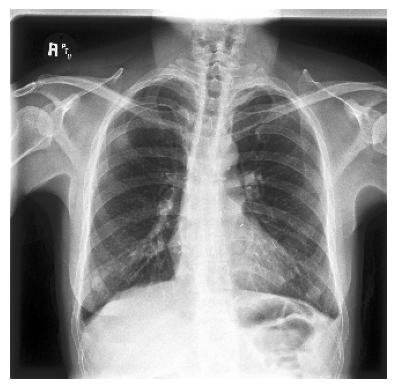

In [52]:
row_random = df_matched.sample(1).iloc[0]
print("Report :")
print(row_random["report"])
print()
print("section_impression :")
print(row_random["section_impression"])
print()
print('section_findings :')
print(row_random['section_findings'])

img = Image.open(row_random["local_image_path"])
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

Le modèle multimodal a besoin d'un seul texte de référence par image. Nous allons donc créer une colonne "report_text" qui sera utilisée par tous les modèles NLP du projet. Cette colonne sera alimentée comme suit : 

--> La section "impression" correspond généralement à la conclusion diagnostique du radiologue. C'est donc notre source prioritaire.

--> Lorsque cette section est absente ou vide nous pouvons utiliser la section "findings" qui contient les observations détaillées.

Les rapports totalement vides seront supprimés car ils ne contiennent aucune information exploitable

In [53]:
# Remplacre les valeurs manquantes par une chaîne vide dans la section "impression"
df_matched["section_impression"] = df_matched["section_impression"].fillna("")

# Idem pour "findings"
df_matched["section_findings"] = df_matched["section_findings"].fillna("")

# On utilise d'abord la conclusion médicale (impression)
df_matched["report_text"] = df_matched["section_impression"].str.strip()

# Identification des lignes où la conclusion médicale est vide
mask_empty = df_matched["report_text"] == ""

# Si la conclusion est vide, on utilise les observations détaillées (findings)
df_matched.loc[mask_empty, "report_text"] = (df_matched.loc[mask_empty, "section_findings"].str.strip())

# Suppression des lignes dont le texte final est vide
df_matched = df_matched[df_matched["report_text"] != ""].copy()

In [56]:
cols_to_keep = [
    "local_image_path",
    "path_norm",
    "path_to_image",
    "deid_patient_id",
    "patient_report_date_order",
    "frontal_lateral",
    "ap_pa",
    "report",
    "report_text",
    "section_findings",
    "section_impression",
    "age",
    "sex",
    "split"
]

In [58]:

df_final = df_matched[cols_to_keep].copy()

df_final.to_csv("../data/processed/matched_image_reports.csv", index=False)